Just for sanity check of the integrity of data provided by `EquityCalculator.exe`

In [134]:
# Read the equity matrix from the binary file and reshape it into a 169x169 matrix
import numpy as np
file_path: str = r".\equity_169x169_matrix.bin"
equity_matrix: np.ndarray = np.fromfile(file_path, dtype=np.float32)
equity_matrix = equity_matrix.reshape((169, 169))
np.set_printoptions(precision=4, suppress=True, linewidth=150)

sanity_check_matrix = equity_matrix[:10, :10]

print("=== Sanity Check: Top-left 10x10 Equity Matrix ===")
print(sanity_check_matrix)

=== Sanity Check: Top-left 10x10 Equity Matrix ===
[[0.5    0.8784 0.8747 0.8704 0.8668 0.8844 0.8804 0.8806 0.8821 0.8673]
 [0.1216 0.5    0.7125 0.7105 0.7073 0.7117 0.7098 0.7068 0.7091 0.6978]
 [0.1253 0.2875 0.5    0.708  0.7053 0.7066 0.7042 0.7052 0.7045 0.6936]
 [0.1296 0.2895 0.292  0.5    0.6989 0.7005 0.698  0.6963 0.6991 0.6844]
 [0.1332 0.2927 0.2947 0.3011 0.5    0.6913 0.6893 0.6863 0.6869 0.6761]
 [0.1156 0.2883 0.2934 0.2995 0.3087 0.5    0.6667 0.665  0.6644 0.6509]
 [0.1196 0.2902 0.2958 0.302  0.3107 0.3333 0.5    0.6443 0.6444 0.63  ]
 [0.1194 0.2932 0.2948 0.3037 0.3137 0.335  0.3557 0.5    0.6149 0.602 ]
 [0.1179 0.2909 0.2955 0.3009 0.3131 0.3356 0.3556 0.3851 0.5    0.567 ]
 [0.1327 0.3022 0.3064 0.3156 0.3239 0.3491 0.37   0.398  0.433  0.5   ]]


In [135]:
# specific hand equity checks
rank: dict[str, int] = {'A':0, 'K':1, 'Q':2, 'J':3, 'T':4, '9':5, '8':6, '7':7, '6':8, '5':9, '4':10, '3':11, '2':12}

hero_hand: str = "AKs"
villain_hand: str = "AXs"

def hand_to_index(hand: str) -> int:
    rank1, rank2 = hand[0], hand[1]
    idx1, idx2 = rank[rank1], rank[rank2]
    if idx1 == idx2:
        return idx1 * 13 + idx2
    elif hand[2] == 's':
        return min(idx1, idx2) * 13 + max(idx1, idx2)
    else:
        return max(idx1, idx2) * 13 + min(idx1, idx2)
hero_idx: int = hand_to_index(hero_hand)

for villain_ace_high in ['K', 'Q', 'J', 'T', '9', '8', '7', '6']:
    villain_hand = f"A{villain_ace_high}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")
    
print("    --- wheels below ---")
for villain_wheel in ['5', '4', '3', '2']:
    villain_hand = f"A{villain_wheel}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")

Equity of AKs vs AKs: 0.5000
Equity of AKs vs AQs: 0.7125
Equity of AKs vs AJs: 0.7105
Equity of AKs vs ATs: 0.7073
Equity of AKs vs A9s: 0.7117
Equity of AKs vs A8s: 0.7098
Equity of AKs vs A7s: 0.7068
Equity of AKs vs A6s: 0.7091
    --- wheels below ---
Equity of AKs vs A5s: 0.6978
Equity of AKs vs A4s: 0.7024
Equity of AKs vs A3s: 0.7068
Equity of AKs vs A2s: 0.7106


=== Rquity of JJ against range ===
Range Equity: 0.7747
=== Breakdown of Equity of JJ against all other hands ===
[[0.1883 0.5403 0.5412 0.6551 0.6784 0.6845 0.6808 0.6797 0.6848 0.6668 0.6702 0.6741 0.6781]
 [0.5685 0.1846 0.537  0.6448 0.6773 0.6833 0.6871 0.6845 0.6857 0.6819 0.686  0.6892 0.6927]
 [0.5694 0.5645 0.1804 0.6305 0.6728 0.6786 0.6824 0.687  0.6871 0.6834 0.6869 0.6902 0.6941]
 [0.6945 0.683  0.6673 0.5    0.8218 0.8391 0.8524 0.866  0.8791 0.8747 0.8784 0.8827 0.8867]
 [0.7144 0.7132 0.7082 0.8703 0.8196 0.8167 0.8181 0.8195 0.8233 0.835  0.8348 0.8384 0.843 ]
 [0.7208 0.7199 0.7147 0.8892 0.8582 0.8163 0.8029 0.8048 0.8086 0.8198 0.8365 0.8365 0.8407]
 [0.7169 0.7238 0.7191 0.9034 0.8588 0.8431 0.8122 0.7898 0.7936 0.805  0.8215 0.8378 0.8379]
 [0.7154 0.7205 0.723  0.9176 0.86   0.8446 0.8288 0.8093 0.7829 0.7905 0.8068 0.8233 0.8394]
 [0.7212 0.722  0.7233 0.932  0.8643 0.8485 0.833  0.8209 0.8097 0.7791 0.7954 0.8119 0.8286]
 [0.7019 0.718  0.719  0.9274 0.8766 0.8

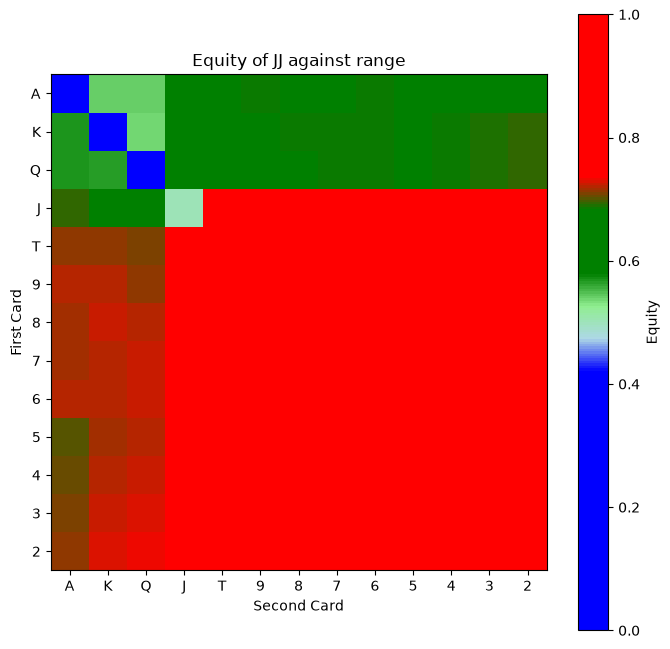

In [136]:
# Equity of a specific hand against all other hands
specific_hand: str = "JJ"
specific_idx: int = hand_to_index(specific_hand)

specific_equity_matrix: np.ndarray = equity_matrix[specific_idx, :].reshape((13, 13))

FREQUENCY: list[int] = [ 6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6]
FREQUENCY_MATRIX: np.ndarray = np.array(FREQUENCY, dtype=np.float64)
def get_frequency_matrix(hand_idx: int)->np.ndarray:
    actual_frequency: np.ndarray = FREQUENCY_MATRIX.copy().reshape(13, 13)
    row: int = hand_idx//13
    col: int = hand_idx%13
    if (row==col): # pocket pairs, also it feels so good to unlock modulus
        actual_frequency[row, col] = 4.0 # pocket pair requires further operations to be tuned down to 1
        actual_frequency[row, :] /= 2.0; # blocks half of the combos in the same row
        actual_frequency[:, col] /= 2.0; # blocks half of the combos in the same column
        return actual_frequency.flatten()
    else:
        suited_row, suited_col = (row, col) if row < col else (col, row)
        offsuit_row, offsuit_col = (row, col) if row > col else (col, row)
        actual_frequency[row, col] = 256.0 # suited counterpart requires further operations to be tuned down to 2/3
        actual_frequency[col, row] = 256.0 # offsuit counterpart requires further operations to be tuned down to 6/7
        actual_frequency[row, row], actual_frequency[col, col] = 256.0, 256.0 # involved pocket paris requires further actions to be tuned down to 3
        actual_frequency[row, :] /= 4.0;
        actual_frequency[row, :] *= 3.0;
        actual_frequency[:, col] /= 4.0;
        actual_frequency[:, col] *= 3.0; # blocks 1/4 of the combos in the larger rank
        actual_frequency[col, :] /= 4.0;
        actual_frequency[col, :] *= 3.0;
        actual_frequency[:, row] /= 4.0;
        actual_frequency[:, row] *= 3.0; # blocks 1/4 of the combos in the smaller rank
        actual_frequency[suited_row, suited_col] = 3.0 if row<col else 2.0; # suited counterpart requires further operations to be tuned down to 2/3
        actual_frequency[offsuit_row, offsuit_col] = 6.0 if row<col else 7.0; # offsuit counterpart requires further operations to be tuned down to 6/7
        actual_frequency[row, row], actual_frequency[col, col] = 3.0,3.0;
        return actual_frequency.flatten()

print(f"=== Rquity of {specific_hand} against range ===")
print(f"Range Equity: {(specific_equity_matrix.flatten()*get_frequency_matrix(specific_idx)).sum()/1225.0:.4f}")

print(f"=== Breakdown of Equity of {specific_hand} against all other hands ===")
print(specific_equity_matrix)
    
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# heatmap of the 13x13 equity matrix. Red for 0.0 equity, and Green for 1.0 equity
plt.figure(figsize=(8, 8))
colors = ['Blue']*9 + ['lightBlue'] + ['lightGreen'] +  ['Green']*3 + ['red']*6
custom_gradient = LinearSegmentedColormap.from_list('my_gradient', colors)
plt.imshow(specific_equity_matrix, cmap=custom_gradient, vmin=0, vmax=1)
plt.colorbar(label='Equity')
plt.xticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.yticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.xlabel('Second Card')
plt.ylabel('First Card')
plt.title(f'Equity of {specific_hand} against range')
plt.show()

**Blue**: Being Dominated (Equity < 45%)

**White**: Coin Flip (45% < Equity < 55%)

**Green**: Slight Advantage (55% < Equity < 70%)

**Red**: Dominating (70% < Equity)